# Desafío Regresión 1 — Desarrollo

Este notebook desarrolla el desafío usando las herramientas revisadas en la clase de regresión lineal: preparación de datos, análisis exploratorio, variables binarias, modelos lineales con `sklearn`, evaluación con `R²`, prueba de hipótesis y depuración del modelo con apoyo de `statsmodels`.

**Base utilizada:** `Credit.csv`  
**Variable objetivo:** `Balance`

In [5]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

## Ejercicio 1: Preparación del ambiente de trabajo

Primero se importa la base `Credit.csv`, se elimina la columna `Unnamed: 0` y se revisan las frecuencias de las variables categóricas para decidir cómo generar variables binarias.

In [6]:
credit_path = Path("Credit.csv")
if not credit_path.exists():
    credit_path = Path("/mnt/data/Credit.csv")

df = pd.read_csv(credit_path)
df = df.drop(columns=["Unnamed: 0"])

df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [7]:
categorical_columns = ["Gender", "Student", "Married", "Ethnicity"]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("\nProporción:")
    print((df[col].value_counts(normalize=True) * 100).round(2).astype(str) + "%")


Gender
Gender
Female    207
 Male     193
Name: count, dtype: int64

Proporción:
Gender
Female    51.75%
 Male     48.25%
Name: proportion, dtype: object

Student
Student
No     360
Yes     40
Name: count, dtype: int64

Proporción:
Student
No     90.0%
Yes    10.0%
Name: proportion, dtype: object

Married
Married
Yes    245
No     155
Name: count, dtype: int64

Proporción:
Married
Yes    61.25%
No     38.75%
Name: proportion, dtype: object

Ethnicity
Ethnicity
Caucasian           199
Asian               102
African American     99
Name: count, dtype: int64

Proporción:
Ethnicity
Caucasian           49.75%
Asian                25.5%
African American    24.75%
Name: proportion, dtype: object


Se generan variables binarias. Para `Ethnicity`, se deja `Caucasian` como categoría de referencia y se crean `AfricanAmerican` y `Asian`, tal como pide el desafío.

In [8]:
# Limpiar espacio inicial en la variable Gender
df["Gender"] = df["Gender"].str.strip()

# Binarias para grupos minoritarios o categorías de interés
df["Male"] = np.where(df["Gender"] == "Male", 1, 0)
df["Student"] = np.where(df["Student"] == "Yes", 1, 0)
df["Unmarried"] = np.where(df["Married"] == "No", 1, 0)
df["AfricanAmerican"] = np.where(df["Ethnicity"] == "African American", 1, 0)
df["Asian"] = np.where(df["Ethnicity"] == "Asian", 1, 0)

# DataFrame listo para modelar
df_model = df.drop(columns=["Gender", "Married", "Ethnicity"])

df_model.head()

,Income,Limit,Rating,Cards,Age,Education,Student,Balance,Male,Unmarried,AfricanAmerican,Asian
0,14.891,3606,283,2,34,11,0,333,1,0,0,0
1,106.025,6645,483,3,82,15,1,903,0,0,0,1
2,104.593,7075,514,4,71,11,0,580,1,1,0,1
3,148.924,9504,681,3,36,11,0,964,0,1,0,1
4,55.882,4897,357,2,68,16,0,331,1,0,0,0


In [9]:
df_model.describe().round(2)

,Income,Limit,Rating,Cards,Age,Education,Student,Balance,Male,Unmarried,AfricanAmerican,Asian
count,400.00,400.00,400.00,400.00,400.00,400.00,400.0,400.00,400.00,400.00,400.00,400.00
mean,45.22,4735.60,354.94,2.96,55.67,13.45,0.1,520.02,0.48,0.39,0.25,0.26
std,35.24,2308.20,154.72,1.37,17.25,3.13,0.3,459.76,0.50,0.49,0.43,0.44
min,10.35,855.00,93.00,1.00,23.00,5.00,0.0,0.00,0.00,0.00,0.00,0.00
25%,21.01,3088.00,247.25,2.00,41.75,11.00,0.0,68.75,0.00,0.00,0.00,0.00
50%,33.12,4622.50,344.00,3.00,56.00,14.00,0.0,459.50,0.00,0.00,0.00,0.00
75%,57.47,5872.75,437.25,4.00,70.00,16.00,0.0,863.00,1.00,1.00,0.00,1.00
max,186.63,13913.00,982.00,9.00,98.00,20.00,1.0,1999.00,1.00,1.00,1.00,1.00


## Ejercicio 2: Análisis exploratorio

Se crea la función `plot_hist`, que grafica un histograma e incorpora líneas verticales para la media y la mediana.

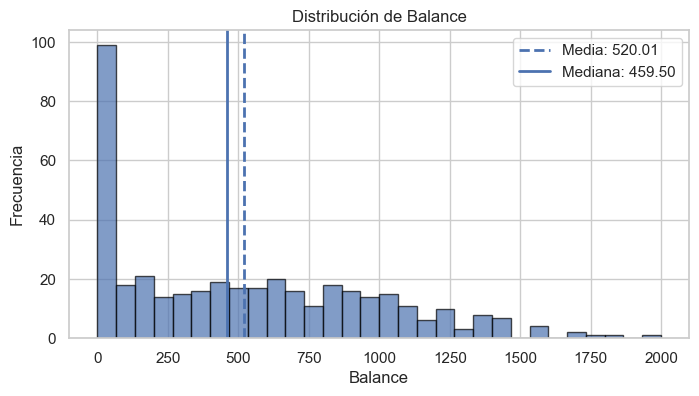

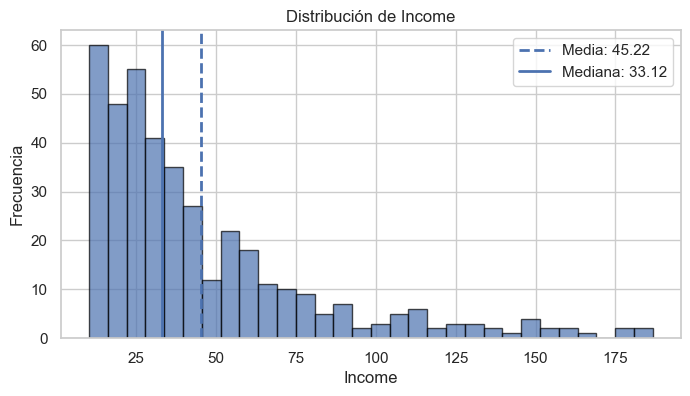

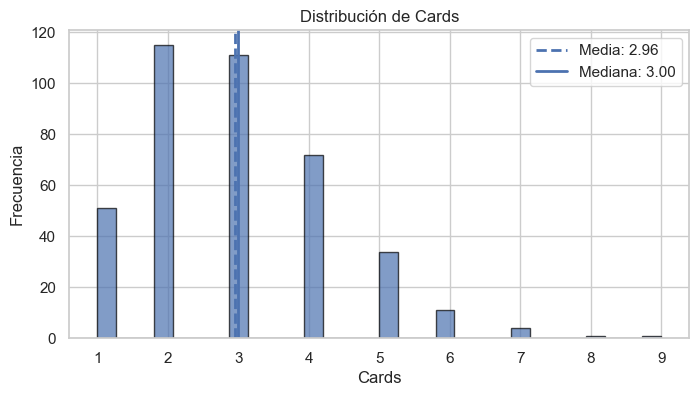

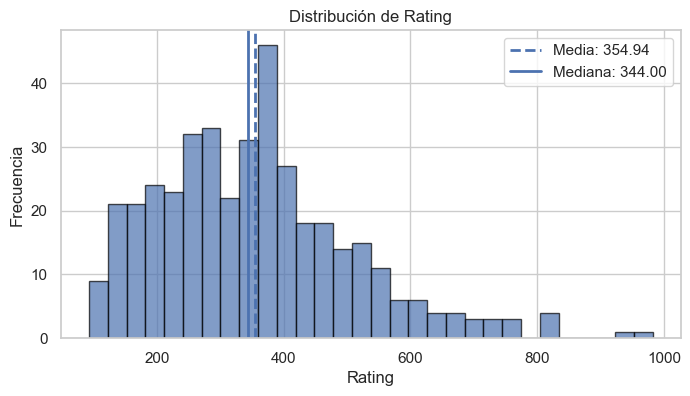

In [10]:
def plot_hist(dataframe, variable, bins=30):
    """Genera histograma con media y mediana para una variable numérica."""
    mean_value = dataframe[variable].mean()
    median_value = dataframe[variable].median()

    plt.figure(figsize=(8, 4))
    plt.hist(dataframe[variable], bins=bins, edgecolor="black", alpha=0.7)
    plt.axvline(mean_value, linestyle="--", linewidth=2, label=f"Media: {mean_value:.2f}")
    plt.axvline(median_value, linestyle="-", linewidth=2, label=f"Mediana: {median_value:.2f}")
    plt.title(f"Distribución de {variable}")
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.show()

for variable in ["Balance", "Income", "Cards", "Rating"]:
    plot_hist(df_model, variable)

In [11]:
df_model[["Balance", "Income", "Cards", "Rating"]].describe().round(2)

,Balance,Income,Cards,Rating
count,400.00,400.00,400.00,400.00
mean,520.02,45.22,2.96,354.94
std,459.76,35.24,1.37,154.72
min,0.00,10.35,1.00,93.00
25%,68.75,21.01,2.00,247.25
50%,459.50,33.12,3.00,344.00
75%,863.00,57.47,4.00,437.25
max,1999.00,186.63,9.00,982.00


In [12]:
df_model[["Balance", "Income", "Cards", "Rating"]].skew().round(3)

Balance    0.585
Income     1.742
Cards      0.792
Rating     0.865
dtype: float64

**Comentario exploratorio**

- `Balance` presenta alta dispersión y sesgo positivo moderado: hay varios clientes con deuda baja o cero, pero también casos con deuda mucho más alta.
- `Income` muestra sesgo positivo fuerte: la mayoría de los ingresos se concentra en valores bajos o medios, con algunos ingresos altos.
- `Cards` es discreta y se concentra principalmente entre 2 y 4 tarjetas.
- `Rating` también presenta sesgo positivo: la mayoría de los clientes tiene rating medio, con algunos ratings muy altos.

## Ejercicio 3: Regresión lineal simple

Se estiman tres modelos simples con `sklearn`:

\[
Balance = \beta_0 + \gamma_1 \cdot Student + \epsilon
\]

\[
Balance = \beta_0 + \gamma_1 \cdot Income + \epsilon
\]

\[
Balance = \beta_0 + \gamma_1 \cdot Rating + \epsilon
\]

In [13]:
def fit_simple_model(dataframe, regressor, target="Balance"):
    X = dataframe[[regressor]]
    y = dataframe[target]

    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)
    yhat = model.predict(X)

    return {
        "regresor": regressor,
        "intercepto": model.intercept_,
        "pendiente": model.coef_[0],
        "R2": r2_score(y, yhat),
        "MSE": mean_squared_error(y, yhat)
    }

simple_results = pd.DataFrame([
    fit_simple_model(df_model, "Student"),
    fit_simple_model(df_model, "Income"),
    fit_simple_model(df_model, "Rating")
])

simple_results.round(4)

,regresor,intercepto,pendiente,R2,MSE
0,Student,480.3694,396.4556,0.0671,196703.8491
1,Income,246.5148,6.0484,0.2150,165521.8613
2,Rating,-390.8463,2.5662,0.7458,53587.8051


**Comentario**

El modelo simple con mayor poder explicativo es el que utiliza `Rating`, porque alcanza el mayor `R²`. Esto indica que `Rating` explica una mayor proporción de la variabilidad de `Balance` en comparación con `Student` e `Income` por separado.

`Student` tiene un efecto positivo relevante en promedio: los estudiantes presentan mayor deuda promedio en tarjeta que los no estudiantes. Sin embargo, como modelo simple explica menos varianza que `Income` y mucho menos que `Rating`.

In [14]:
balance_students = df_model.loc[df_model["Student"] == 1, "Balance"]
balance_non_students = df_model.loc[df_model["Student"] == 0, "Balance"]

ttest_student = stats.ttest_ind(balance_students, balance_non_students, equal_var=False)

print(f"Media Balance estudiantes: {balance_students.mean():.2f}")
print(f"Media Balance no estudiantes: {balance_non_students.mean():.2f}")
print(f"Estadístico t: {ttest_student.statistic:.4f}")
print(f"p-value: {ttest_student.pvalue:.8f}")

Media Balance estudiantes: 876.83
Media Balance no estudiantes: 480.37
Estadístico t: 4.9028
p-value: 0.00001205


La prueba t para muestras independientes muestra un `p-value` muy bajo, por lo que se rechaza la hipótesis nula de igualdad de medias. En estos datos, la deuda promedio de los estudiantes es significativamente distinta, y mayor, que la de los no estudiantes.

## Ejercicio 4: Modelo con todos los regresores

Ahora se estima un modelo múltiple con todos los predictores disponibles después de la preparación de datos.

In [15]:
y = df_model["Balance"]
X = df_model.drop(columns=["Balance"])

# Modelo sklearn para obtener predicción y R2
full_sklearn = LinearRegression(fit_intercept=True)
full_sklearn.fit(X, y)
full_yhat = full_sklearn.predict(X)

print(f"R2 modelo completo sklearn: {r2_score(y, full_yhat):.4f}")
print(f"MSE modelo completo sklearn: {mean_squared_error(y, full_yhat):.2f}")

# Modelo statsmodels para analizar significancia
X_sm = sm.add_constant(X)
full_model = sm.OLS(y, X_sm).fit()
full_model.summary()

R2 modelo completo sklearn: 0.9551
MSE modelo completo sklearn: 9466.83


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     750.3
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          1.11e-253
Time:                        01:15:10   Log-Likelihood:                -2398.7
No. Observations:                 400   AIC:                             4821.
Df Residuals:                     388   BIC:                             4869.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            -488.2880     34.816    -14.025      0.000    -556.740    -419.836
Income             -7.8031      0.234    -33.314      0.000      -8.264      -7.343
Limit               0.1909      0.033      5.824      0.000       0.126       0.255
Rating              1.1365      0.491      2.315      0.021       0.171       2.102
Cards              17.7245      4.341      4.083      0.000       9.190      26.259
Age                -0.6139      0.294     -2.088      0.037      -1.192      -0.036
Education          -1.0989      1.598     -0.688      0.492      -4.241       2.043
Student           425.7474     16.723     25.459      0.000     392.869     458.626
Male               10.6532      9.914      1.075      0.283      -8.839      30.145
Unmarried           8.5339     10.363      0.824      0.411     -11.841      28.908
AfricanAmerican   -10.1070     12.210     -0.828      0.408     -34.113      13.899
Asian               6.6972     12.122      0.552      0.581     -17.137      30.531
==============================================================================
Omnibus:                       34.899   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               41.766
Skew:                           0.782   Prob(JB):                     8.52e-10
Kurtosis:                       3.241   Cond. No.                     3.74e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.74e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [16]:
coef_table = pd.DataFrame({
    "coeficiente": full_model.params,
    "p_value": full_model.pvalues
}).round(4)

coef_table.sort_values("p_value")

,coeficiente,p_value
const,-488.2880,0.0000
Income,-7.8031,0.0000
Limit,0.1909,0.0000
Student,425.7474,0.0000
Cards,17.7245,0.0001
Rating,1.1365,0.0211
Age,-0.6139,0.0374
Male,10.6532,0.2832
AfricanAmerican,-10.1070,0.4083
Unmarried,8.5339,0.4107


**Comentario**

El modelo completo presenta un poder explicativo alto, con un `R²` cercano a 0.955. Las variables con mayor evidencia estadística en el modelo completo son principalmente `Income`, `Limit`, `Student`, `Cards` y `Rating`. 

El signo negativo de `Income` en el modelo múltiple no debe interpretarse igual que en el modelo simple, porque ahora se controla por variables como `Limit` y `Rating`. Esto sugiere que, manteniendo constante el límite y el rating, mayores ingresos se asocian con menor deuda promedio.

## Ejercicio 5: Depuración del modelo

Se refactoriza el modelo incluyendo sólo las variables con `p-value <= 0.025` según el modelo completo.

In [17]:
significant_predictors = (
    full_model.pvalues[full_model.pvalues <= 0.025]
    .drop(labels="const", errors="ignore")
    .index
    .tolist()
)

significant_predictors

['Income', 'Limit', 'Rating', 'Cards', 'Student']

In [18]:
X_reduced = sm.add_constant(df_model[significant_predictors])
reduced_model = sm.OLS(y, X_reduced).fit()

reduced_yhat = reduced_model.predict(X_reduced)

comparison = pd.DataFrame({
    "modelo": ["Completo", "Reducido"],
    "n_predictores": [X.shape[1], len(significant_predictors)],
    "R2": [full_model.rsquared, reduced_model.rsquared],
    "R2_ajustado": [full_model.rsquared_adj, reduced_model.rsquared_adj],
    "MSE": [
        mean_squared_error(y, full_yhat),
        mean_squared_error(y, reduced_yhat)
    ],
    "AIC": [full_model.aic, reduced_model.aic]
})

comparison.round(4)

,modelo,n_predictores,R2,R2_ajustado,MSE,AIC
0,Completo,11,0.9551,0.9538,9466.8255,4821.3704
1,Reducido,5,0.9542,0.9536,9665.2280,4817.6668


In [19]:
reduced_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                Balance   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     1640.
Date:                Wed, 01 Jul 2026   Prob (F-statistic):          3.60e-261
Time:                        01:15:10   Log-Likelihood:                -2402.8
No. Observations:                 400   AIC:                             4818.
Df Residuals:                     394   BIC:                             4842.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -526.1555     19.747    -26.645      0.000    -564.977    -487.334
Income        -7.8749      0.231    -34.024      0.000      -8.330      -7.420
Limit          0.1944      0.033      5.977      0.000       0.130       0.258
Rating         1.0879      0.487      2.234      0.026       0.130       2.045
Cards         17.8517      4.335      4.118      0.000       9.329      26.374
Student      426.8501     16.574     25.754      0.000     394.266     459.435
==============================================================================
Omnibus:                       30.263   Durbin-Watson:                   1.949
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               35.257
Skew:                           0.722   Prob(JB):                     2.21e-08
Kurtosis:                       3.179   Cond. No.                     2.12e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.12e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Comentario**

La reducción de regresores disminuye levemente el `R²`, pero mantiene prácticamente el mismo poder explicativo y mejora la parsimonia del modelo. Además, el `AIC` del modelo reducido es menor, lo que favorece al modelo más simple.

En términos sustantivos, los principales predictores son:

- `Limit`: mayor límite de crédito se asocia con mayor `Balance`.
- `Student`: ser estudiante se asocia con un aumento importante en el promedio de deuda.
- `Income`: controlando por los demás predictores, se asocia negativamente con `Balance`.
- `Cards`: más tarjetas se asocian con mayor `Balance`.
- `Rating`: queda como predictor relevante desde el modelo completo, aunque en el modelo reducido puede quedar muy cerca del umbral de significancia.

## Ejercicio 6: Inspección de comportamientos con `lmplot`

Finalmente, se inspecciona visualmente la relación entre `Balance` y sus principales determinantes.

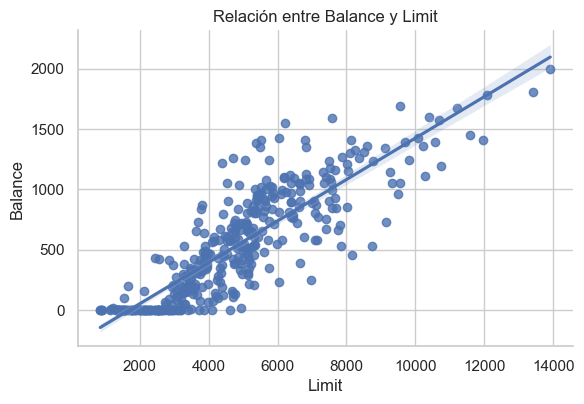

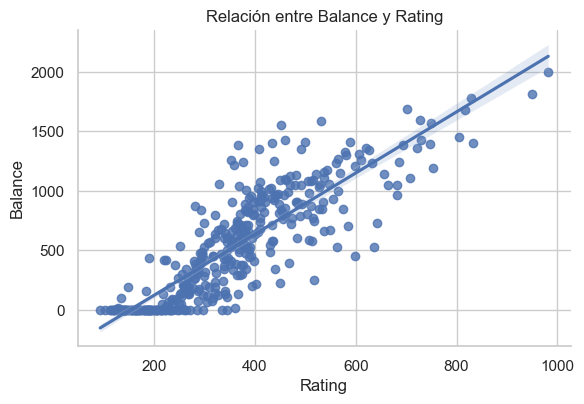

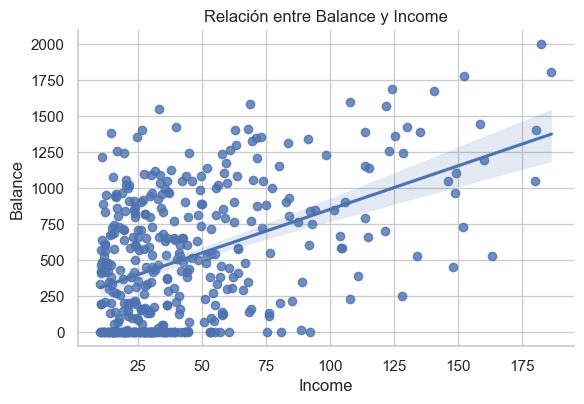

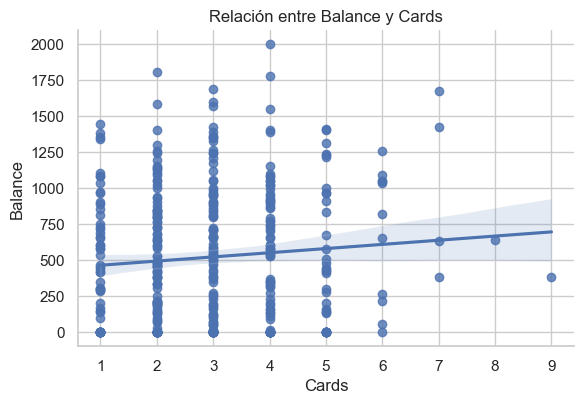

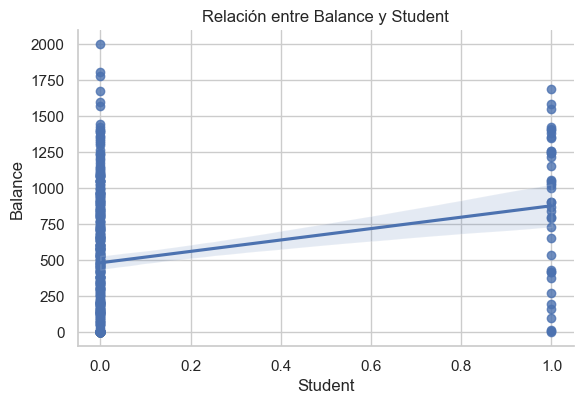

In [20]:
for variable in ["Limit", "Rating", "Income", "Cards", "Student"]:
    sns.lmplot(data=df_model, x=variable, y="Balance", height=4, aspect=1.5)
    plt.title(f"Relación entre Balance y {variable}")
    plt.show()

## Conclusión general

El determinante simple más fuerte de `Balance` es `Rating`. Sin embargo, al estimar un modelo múltiple, el promedio de deuda en tarjeta se explica mejor por una combinación de variables financieras y de perfil del cliente, especialmente `Limit`, `Income`, `Student`, `Cards` y `Rating`.

El modelo reducido es preferible para una entrega aplicada porque conserva casi todo el poder explicativo del modelo completo, pero utiliza menos variables y resulta más interpretable.